In [3]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from imblearn.over_sampling import SMOTE


## 1. Load & Inspect Training Data

In [4]:
# FIX: train.csv columns are product_name, review_text, sentiment  (not full_text)
df = pd.read_csv("train.csv")
df.columns = df.columns.str.strip().str.lower()

print("Columns :", df.columns.tolist())
print("Shape   :", df.shape)
print()
print("Sentiment value counts (original 3-class):")
print(df["sentiment"].value_counts())
df.head()


Columns : ['product_name', 'review_text', 'sentiment']
Shape   : (2194, 3)

Sentiment value counts (original 3-class):
sentiment
2.0    1026
0.0     621
1.0     546
Name: count, dtype: int64


,product_name,review_text,sentiment
0,Basic Online Course Learning (BOCL),"Materinya goks abis, auto paham! Instrukturnya...",2.0
1,Premium Online Learning (POL),"Platformnya anjay, interaktif banget, jadi gak...",2.0
2,Private Online Course Learning (POCL),"Mentornya pro player, ngajarnya santuy tapi ng...",2.0
3,Onsite Course Learning (OCL),"Sumpah, ini kursus paling oke! Ilmunya kepake ...",2.0
4,Private Course Onsite Learning (PCOL),Sertifikatnya nampol buat naikin CV. Vibes bel...,2.0


## 2. Text Cleaning

In [5]:
def clean_text(text):
    text = str(text)
    text = text.replace('"', '').replace("'", "")
    text = text.lower()
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_text"] = df["review_text"].apply(clean_text)
df[["review_text", "clean_text"]].head(5)


,review_text,clean_text
0,"Materinya goks abis, auto paham! Instrukturnya...",materinya goks abis auto paham instrukturnya j...
1,"Platformnya anjay, interaktif banget, jadi gak...",platformnya anjay interaktif banget jadi gak m...
2,"Mentornya pro player, ngajarnya santuy tapi ng...",mentornya pro player ngajarnya santuy tapi nge...
3,"Sumpah, ini kursus paling oke! Ilmunya kepake ...",sumpah ini kursus paling oke ilmunya kepake ba...
4,Sertifikatnya nampol buat naikin CV. Vibes bel...,sertifikatnya nampol buat naikin cv vibes bela...


## 3. Label Mapping (3-class → Binary)

| Original | Meaning  | Binary |
|----------|----------|--------|
| 0        | Negative | 0      |
| 1        | Neutral  | 0      |
| 2        | Positive | 1      |

Binary label distribution:
label
0    1168
1    1026
Name: count, dtype: int64


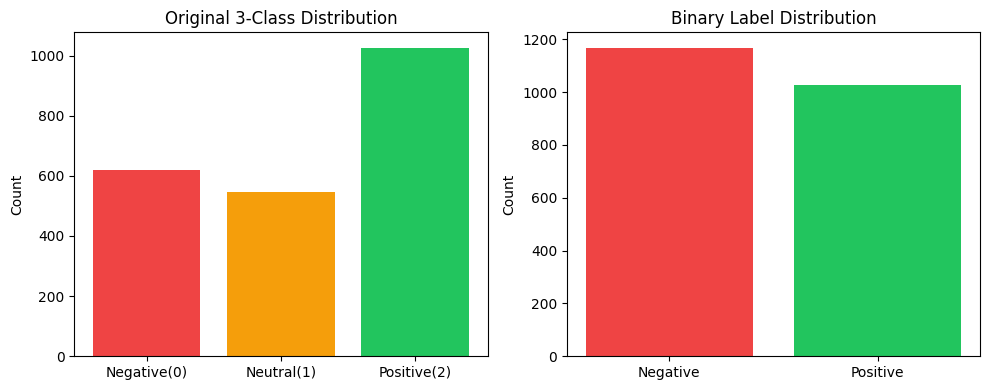

In [6]:
# FIX: use the real sentiment column; map to binary
df["label"] = df["sentiment"].map({0: 0, 1: 0, 2: 1}).fillna(0).astype(int)

print("Binary label distribution:")
print(df["label"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
orig_counts = df["sentiment"].value_counts().sort_index()
axes[0].bar(["Negative(0)","Neutral(1)","Positive(2)"], orig_counts.values, color=["#ef4444","#f59e0b","#22c55e"])
axes[0].set_title("Original 3-Class Distribution")
axes[0].set_ylabel("Count")

bin_counts = df["label"].value_counts().sort_index()
axes[1].bar(["Negative","Positive"], bin_counts.values, color=["#ef4444","#22c55e"])
axes[1].set_title("Binary Label Distribution")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


## 4. TF-IDF Vectorization & Train/Validation Split

In [7]:
X = df["clean_text"]
y = df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)

print(f"Train: {X_train_tfidf.shape}, Val: {X_val_tfidf.shape}")


Train: (1755, 1593), Val: (439, 1593)


## 5. SMOTE Oversampling

After SMOTE: Counter({1: 934, 0: 934})


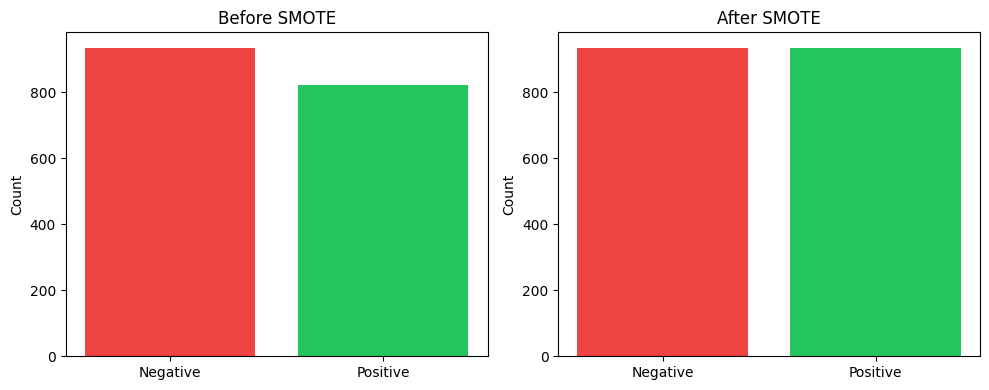

In [8]:
min_samples = int(y_train.value_counts().min())
k = min(5, min_samples - 1)
sm = SMOTE(random_state=42, k_neighbors=k)
X_train_res, y_train_res = sm.fit_resample(X_train_tfidf, y_train)

print("After SMOTE:", Counter(y_train_res))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Negative","Positive"], [y_train.value_counts()[0], y_train.value_counts()[1]],
            color=["#ef4444","#22c55e"])
axes[0].set_title("Before SMOTE"); axes[0].set_ylabel("Count")

after = Counter(y_train_res)
axes[1].bar(["Negative","Positive"], [after[0], after[1]], color=["#ef4444","#22c55e"])
axes[1].set_title("After SMOTE"); axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()


## 6. Train Models

In [9]:
models = {
    "Naive Bayes":          MultinomialNB(),
    "Logistic Regression":  LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "SVM (LinearSVC)":      LinearSVC(class_weight="balanced", max_iter=1000, random_state=42),
}

for name, m in models.items():
    m.fit(X_train_res, y_train_res)
    print(f"{name}: trained ✓")


Naive Bayes: trained ✓
Logistic Regression: trained ✓
SVM (LinearSVC): trained ✓


## 7. Evaluate on Validation Split

In [10]:
val_accuracies = {}

for name, m in models.items():
    preds = m.predict(X_val_tfidf)
    acc   = accuracy_score(y_val, preds)
    val_accuracies[name] = acc
    print(f"=== {name} — Validation Accuracy: {acc*100:.1f}% ===")
    print(classification_report(y_val, preds, target_names=["Negative","Positive"]))
    print()


=== Naive Bayes — Validation Accuracy: 100.0% ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       234
    Positive       1.00      1.00      1.00       205

    accuracy                           1.00       439
   macro avg       1.00      1.00      1.00       439
weighted avg       1.00      1.00      1.00       439


=== Logistic Regression — Validation Accuracy: 100.0% ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       234
    Positive       1.00      1.00      1.00       205

    accuracy                           1.00       439
   macro avg       1.00      1.00      1.00       439
weighted avg       1.00      1.00      1.00       439


=== SVM (LinearSVC) — Validation Accuracy: 100.0% ===
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       234
    Positive       1.00      1.00      1.00       205

    accuracy      

## 8. Load & Parse Test Dataset

> **FIX:** `test.csv` has malformed quoting — the label is embedded inside the quoted text field.
> A custom parser extracts text and label correctly.

In [11]:
def load_test_csv(path="test.csv"):
    """
    test.csv rows look like:
        "\"text content here\", 0"
    The label is embedded at the end of the outer quoted string.
    """
    with open(path, "r", encoding="utf-8-sig") as f:
        raw = f.read()

    lines = raw.splitlines()
    records = []
    for line in lines[1:]:
        line = line.strip()
        if not line:
            continue
        if line.startswith('"') and line.endswith('"'):
            line = line[1:-1]
        m = re.match(r'^(.*),\s*([01])\s*$', line)
        if m:
            text  = m.group(1).strip().strip('"')
            label = int(m.group(2))
            records.append({"text": text, "label": label})

    return pd.DataFrame(records)

test_df = load_test_csv("test.csv")
test_df["clean_text"] = test_df["text"].apply(clean_text)

print("Test set shape:", test_df.shape)
print("Label distribution:")
print(test_df["label"].value_counts())
test_df.head()


Test set shape: (36, 3)
Label distribution:
label
1    20
0    16
Name: count, dtype: int64


,text,label,clean_text
0,Menurut saya online itu kadang membuat mahasis...,1,menurut saya online itu kadang membuat mahasis...
1,"Menurut saya, kuliah online banyak positifnya,...",1,menurut saya kuliah online banyak positifnya s...
2,Lebih menguntungkan untuk kemudahan akses maha...,1,lebih menguntungkan untuk kemudahan akses maha...
3,"Kurang suka, mudah untuk hilang fokus terhadap...",0,kurang suka mudah untuk hilang fokus terhadap ...
4,kurang efektif,0,kurang efektif


## 9. Evaluate on External Test Set

In [12]:
X_test_tfidf = tfidf.transform(test_df["clean_text"])
y_test        = test_df["label"].values

ext_accuracies = {}

for name, m in models.items():
    preds = m.predict(X_test_tfidf)
    acc   = accuracy_score(y_test, preds)
    ext_accuracies[name] = acc
    print(f"=== {name} — External Test Accuracy: {acc*100:.1f}% ===")
    print(classification_report(y_test, preds, target_names=["Negative","Positive"]))
    print()


=== Naive Bayes — External Test Accuracy: 58.3% ===
              precision    recall  f1-score   support

    Negative       0.52      0.75      0.62        16
    Positive       0.69      0.45      0.55        20

    accuracy                           0.58        36
   macro avg       0.61      0.60      0.58        36
weighted avg       0.62      0.58      0.58        36


=== Logistic Regression — External Test Accuracy: 63.9% ===
              precision    recall  f1-score   support

    Negative       0.62      0.50      0.55        16
    Positive       0.65      0.75      0.70        20

    accuracy                           0.64        36
   macro avg       0.63      0.62      0.62        36
weighted avg       0.64      0.64      0.63        36


=== SVM (LinearSVC) — External Test Accuracy: 61.1% ===
              precision    recall  f1-score   support

    Negative       0.56      0.62      0.59        16
    Positive       0.67      0.60      0.63        20

    accuracy

## 10. Accuracy Comparison Chart

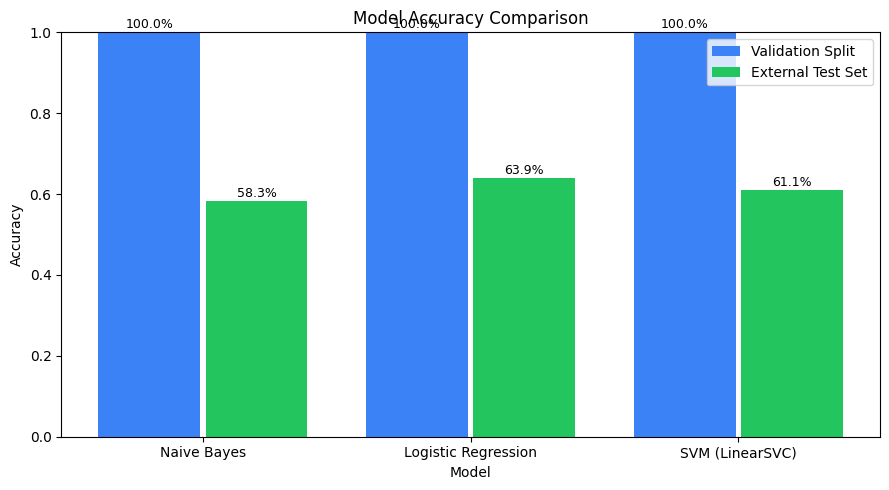

In [13]:
labels    = list(models.keys())
val_vals  = [val_accuracies[m] for m in labels]
ext_vals  = [ext_accuracies[m] for m in labels]
x         = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, val_vals, width=0.38, label="Validation Split",  color="#3b82f6")
ax.bar(x + 0.2, ext_vals, width=0.38, label="External Test Set", color="#22c55e")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_xlabel("Model"); ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison")
ax.set_ylim(0, 1)
ax.legend()

for i, (v, e) in enumerate(zip(val_vals, ext_vals)):
    ax.text(i - 0.2, v + 0.01, f"{v*100:.1f}%", ha='center', fontsize=9)
    ax.text(i + 0.2, e + 0.01, f"{e*100:.1f}%", ha='center', fontsize=9)

plt.tight_layout()
plt.show()


## 11. Confusion Matrices

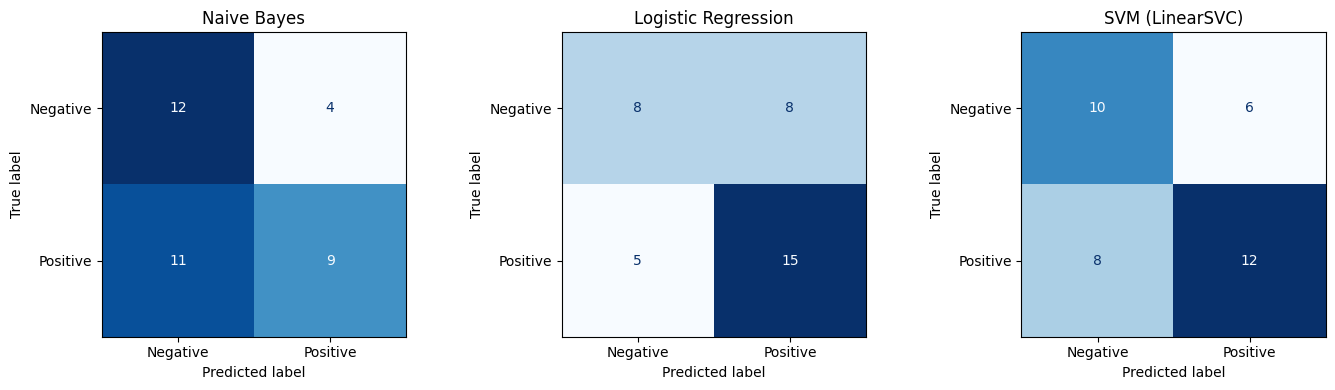

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, m) in zip(axes, models.items()):
    preds = m.predict(X_test_tfidf)
    cm    = confusion_matrix(y_test, preds)
    disp  = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","Positive"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.tight_layout()
plt.show()


## 12. Word Cloud

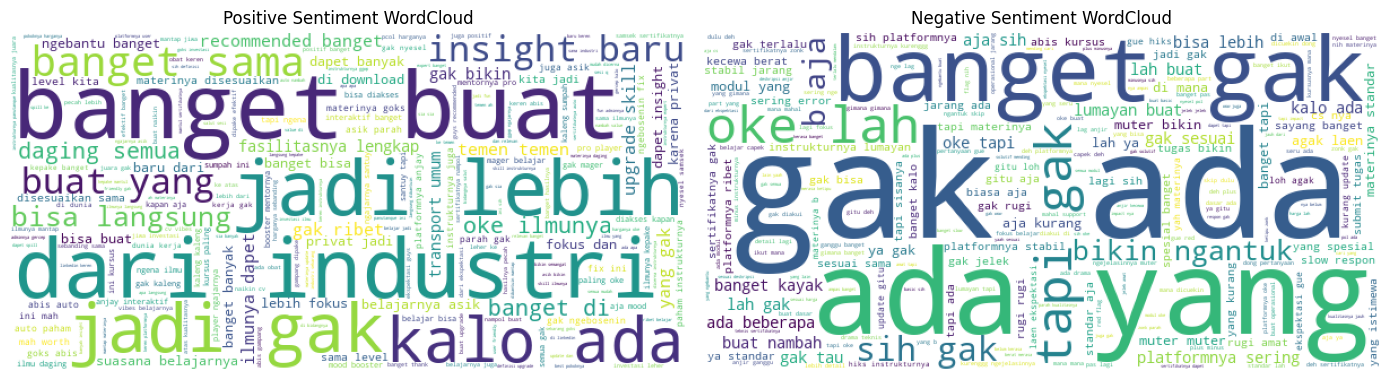

In [15]:
try:
    from wordcloud import WordCloud

    pos_text = " ".join(df[df["label"] == 1]["clean_text"])
    neg_text = " ".join(df[df["label"] == 0]["clean_text"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    wc_pos = WordCloud(width=600, height=300, background_color="white").generate(pos_text)
    axes[0].imshow(wc_pos); axes[0].axis("off"); axes[0].set_title("Positive Sentiment WordCloud")

    wc_neg = WordCloud(width=600, height=300, background_color="white").generate(neg_text)
    axes[1].imshow(wc_neg); axes[1].axis("off"); axes[1].set_title("Negative Sentiment WordCloud")

    plt.tight_layout()
    plt.show()

except ImportError:
    print("wordcloud not installed. Run: pip install wordcloud")


## 13. Save & Load Best Model

In [16]:
import pickle

best_model = models["Logistic Regression"]

pickle.dump(best_model, open("sentiment_model.pkl", "wb"))
pickle.dump(tfidf,      open("tfidf_vectorizer.pkl", "wb"))
print("Model and vectorizer saved.")


Model and vectorizer saved.


In [17]:
loaded_model      = pickle.load(open("sentiment_model.pkl", "rb"))
loaded_vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))
print("Loaded successfully.")


Loaded successfully.


## 14. Quick Inference Test

In [18]:
test_sentences = [
    "Kuliah online sangat membantu dan fleksibel",       # expected: Positive
    "Susah fokus, jaringan sering gangguan, membosankan", # expected: Negative
    "Online learning is very effective and convenient",  # expected: Positive
]

for sentence in test_sentences:
    cleaned = clean_text(sentence)
    vec     = loaded_vectorizer.transform([cleaned])
    pred    = loaded_model.predict(vec)[0]
    proba   = loaded_model.predict_proba(vec)[0]
    label   = "Positive 😊" if pred == 1 else "Negative 😞"
    print(f"{sentence}")
    print(f"  → {label}  (confidence: {max(proba)*100:.1f}%)")
    print()


Kuliah online sangat membantu dan fleksibel
  → Positive 😊  (confidence: 64.9%)

Susah fokus, jaringan sering gangguan, membosankan
  → Negative 😞  (confidence: 55.8%)

Online learning is very effective and convenient
  → Negative 😞  (confidence: 60.6%)

